# Setup


📝 *Import required libraries and files:*

In [20]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import copy
# Text cleaning & preprocessing
import re
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
# Dimensionality reduction
from umap import UMAP
from hdbscan import HDBSCAN
# Topic modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


In [21]:
df = pd.read_parquet("../assets/intermediate_dfs/df_sentiment.parquet") 

# 4.2. - BERTopic modelling

### 4.2.1. - Prepare df for model training

In [22]:
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['word_count'].describe().round(1)

count    653426.0
mean         12.2
std          17.4
min           1.0
25%           2.0
50%           6.0
75%          14.0
max         552.0
Name: word_count, dtype: float64

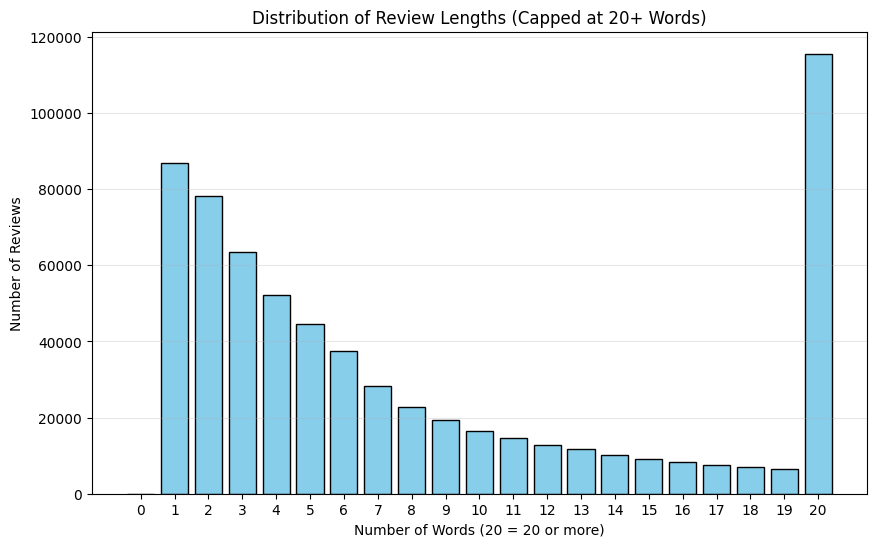

In [23]:
# Calculate number of words per review
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# Cap word counts at 20
df['word_count_capped'] = df['word_count'].apply(lambda x: x if x < 20 else 20)

# Count how many reviews per word count
counts = df['word_count_capped'].value_counts().sort_index()

# Ensure we have bins from 0 to 20 (fill missing ones with 0)
counts = counts.reindex(np.arange(0, 21), fill_value=0)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.title("Distribution of Review Lengths (Capped at 20+ Words)")
plt.xlabel("Number of Words (20 = 20 or more)")
plt.ylabel("Number of Reviews")
plt.xticks(range(0, 21))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [24]:
print (f"Dataframe shape before filtering short reviews: {df.shape}")
# eliminate rows with less than 2 words in 'review_text'
df = df[df['review_text'].str.split().str.len() >= 4]
df = df[df['review_date'] > pd.Timestamp('2021-10-01')]
print (f"Dataframe shape after filtering short reviews: {df.shape}")

Dataframe shape before filtering short reviews: (653426, 22)
Dataframe shape after filtering short reviews: (232719, 22)


In [ ]:
# Setting basic stop words to favor topics related to functionality issues
PRAISE_WORDS = [
    "amazing", "awesome", "brilliant", "excellent", "fantastic", "love", "nice", "perfect", "star", "stars",
    "awful", "bad", "disappointing", "horrible", "poor", "terrible", "useless", "worst"
]

CUSTOM_STOP_WORDS = [
    "santander", "revolut", "revolute", "revoult", "revlout", "revelout", "hsbc", "barclays", 
    "barclay", "lloyds","lloyd", "monzo"
]

STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS

# BERTopic basic cleaning function
def bertopic_cleaning(df: pd.DataFrame, col: str = "review_text"):
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    df[col] = df[col].apply(lambda x: re.sub(r"http\S+", "", str(x))) # Remove URLs
    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces
    
    for w in STOP_WORDS:
        df[col] = df[col].apply(lambda x: re.sub(rf"\b{re.escape(w)}\b", "", x, flags=re.IGNORECASE)) # Remove stop words

    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces again after stop word removal

    return df

In [26]:
# Perform cleaning
df = bertopic_cleaning(df, col="review_text")

In [27]:
print (f"Dataframe shape before filtering short reviews: {df.shape}")
# eliminate rows with less than 3 words in 'review_text'
df = df[df['review_text'].str.split().str.len() >= 2]
print (f"Dataframe shape after filtering short reviews: {df.shape}")

Dataframe shape before filtering short reviews: (232719, 22)
Dataframe shape after filtering short reviews: (232712, 22)


In [28]:
# get a random sample of reviews to speed up initial training
df = df.copy()
reviews = df["review_text"].to_list()

In [29]:
# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(reviews, show_progress_bar=True)

Batches:   0%|          | 0/7273 [00:00<?, ?it/s]

In [30]:
# Create directory one level up from the notebook folder
os.makedirs("../assets/models/bertopic", exist_ok=True)

# Save the file
np.save("../assets/models/bertopic/embeddings.npy", embeddings)

## 4.2.2. - Unseeded topic modelling

### 4.2.2.1. - Model Training

In [31]:
# Load embeddings
embeddings = np.load("../assets/models/bertopic/embeddings.npy")

In [33]:
# Dimensionality reduction tuned for short reviews
umap_model = UMAP(
    n_neighbors=25,           # lower values (5-10) --> more, smaller and tighter clusters; higher values (50-100) --> fewer, larger clusters
    n_components=5,           # number of dimensions to reduce embeddings before clustering. For app reviews 5 tends to be standard
    min_dist=0.0,             # controls how tight we want the clustering to be. 0.0 is recommended for BERTopic --> HDBSCAN works better with tightly packed clusters
    metric="cosine",          # cosine distance is best for text embeddings
    random_state=42)          # ensure reproducibility

# Clustering tuned for short reviews
hdbscan_model = HDBSCAN(
    min_cluster_size=100,      # minimum number of documents required to form a cluster
    cluster_selection_epsilon=0.5,    # Merge clusters within 0.5 distance
    min_samples=None,         # if None, min_samples = min_cluster_size
    metric="euclidean",       # recomended for BERTopic
    cluster_selection_method="eom", 
    prediction_data=True)

# Vectorizer 
STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS + list(ENGLISH_STOP_WORDS)
vectorizer_model = CountVectorizer(
    stop_words= STOP_WORDS,
    ngram_range=(1, 2),       # unigrams and bigrams  
    min_df=10,                 # ignores terms appearing in less than 5 documents
    max_df=0.6                # ignores terms appearing in more than 70% of documents
)

# Create the BERTopic model
unseed_topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",             
    calculate_probabilities=True,   
    min_topic_size=250,
    verbose=True)

In [34]:
topics, probs = unseed_topic_model.fit_transform(reviews, embeddings)

2025-10-21 20:31:34,557 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-21 20:39:27,348 - BERTopic - Dimensionality - Completed ✓
2025-10-21 20:39:27,403 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-21 20:51:49,788 - BERTopic - Cluster - Completed ✓
2025-10-21 20:51:49,901 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 20:51:56,042 - BERTopic - Representation - Completed ✓


In [36]:
# Save Bertopic model 
unseed_topic_model.save("../assets/models/bertopic/unseed_model")

2025-10-21 21:11:52,225 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.2.2. - Model evaluation and finetune

In [37]:
unseed_topic_model = BERTopic.load("../assets/models/bertopic/unseed_model")

In [38]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7997,-1_app easy_use great_good easy_use quick,"[app easy, use great, good easy, use quick, ea...","[Great app,easy to use, Great app easy to use...."
1,0,148888,0_app_account_bank_money,"[app, account, bank, money, great, update, jus...",[New update has resulted in me being locked ou...
2,1,43830,1_works_simple_far_convenient,"[works, simple, far, convenient, efficient, fa...","[works well, does everything I need it to do, ..."
3,2,6798,2_secure_safe_reliable_secure easy,"[secure, safe, reliable, secure easy, security...","[Very easy to us Safe and secure, Safe, secure..."
4,3,5951,3_service_good service_customer_great service,"[service, good service, customer, great servic...","[The service is, Very easy to use the service,..."
5,4,2862,4_paying_pay_branch_work,"[paying, pay, branch, work, taking, feature, d...",[still need to work on the camera recognition ...
6,5,2166,5_use quite_quite easy_quite_use absolutely,"[use quite, quite easy, quite, use absolutely,...","[Quite easy to use, Quite easy to use, Quite e..."
7,6,2038,6_navigate_easy navigate_site_simple,"[navigate, easy navigate, site, simple, clear,...","[Informative and easy to navigate, Easy to nav..."
8,7,1194,7_non_super_plus_care,"[non, super, plus, care, son, os, 20, ok, appl...",[La prima carta che ho ordinato non è arrivata...
9,8,1068,8_experience_experience far_good experience_far,"[experience, experience far, good experience, ...","[Good experience so far, Good experience so fa..."


In [39]:
# Visualize topics as a hierarchical tree
fig = unseed_topic_model.visualize_hierarchy()
fig.show()

In [40]:
# create a new vectorizer with English stop words
GENERAL_WORDS = ["app", "bank", "banking", "great","use","very","easy","extremelly", "get","like","love","good","time","work",
                 "well","new","best","nice","better", "one","make","also","see","want","need","always","much",
                 "still","way","even","look","really","thank","thanks", 'able', 'absolutely', 'accounts', 'add', 'ago', 'alot', 
                 'allows', 'amazing', 'anymore', 'appropriate','awesome', 'bad', 'banking', 'best', 'better', 'bit', 'branch', 
                 'brilliant', 'business', 'change', 'cheque', 'cheques','clear', 'close', 'complicated', 
                 'convenient', 'constantly', 'daily', 'date', 'day', 'days', 'definitely', 'did', 'didnt', 'different', 'difficult', 'does', 
                 'doesnt', 'doing', 'dont', 'ease', 'easier', 'easily', 'easy', 'effective', 'efficient', 'especially', 'exactly', 'excellent', 
                 'experience', 'extremely', 'fab', 'fantastic', 'far', 'fast', 'feels','finances', 'fine', 'fix', 'follow', 'forward', 'getting', 
                 'gives', 'going', 'good', 'google', 'got', 'great', 'guys', 'handy', 'happy', 'havent', 'having', 'hassle', 'hello', 'helpful', 
                 'helps', 'highly', 'hope', 'hoping', 'improved', 'isnt', 'issues', 'job', 'just','keeping', 'keeps', 'know', 'latest', 'let', 
                 'lets', 'life', 'like', 'little', 'live', 'long', 'longer', 'lot', 'lots', 'love', 'loving','make', 'makes', 'making', 'month', 
                 'months', 'need', 'needed', 'needs', 'neo', 'new', 'nice', 'number', 'old', 'online','open', 'overall', 'payees', 'pending', 
                 'people', 'perfect', 'perfectly', 'place', 'pleased', 'poor', 'pretty', 'quick', 'quickly', 'quite', 'really', 'reason', 
                 'recommend', 'recommended', 'reliable', 'rooted', 'round', 'rubbish', 'safe', 'satisfied', 'saves', 'say', 'says', 'set', 
                 'simple', 'simpler', 'simply', 'slow', 'smooth', 'sort', 'star', 'stars', 'stopped', 'straighforward', 'straight', 
                 'straightforward', 'stuff', 'super', 'superb', 'sure', 'takes', 'team', 'terrible', 'thank', 'thats', 'think', 'thing', 
                 'things', 'time', 'times', 'tin', 'tried', 'try', 'trying', 'unable', 'understand', 'use', 'used', 'useful', 'useless', 
                 'using', 'usually', 'want', 'way', 'website', 'went', 'whats', 'wish', 'wonderful', 'wont', 'work', 'worked', 'working', 'works', 
                 'worst', 'wrong', 'years']
NEW_STOP_WORDS = STOP_WORDS + GENERAL_WORDS

new_vectorizer = CountVectorizer(stop_words= NEW_STOP_WORDS , min_df=2, ngram_range=(1, 2))

# update BERTopic’s internal vectorizer
unseed_topic_model.update_topics(
    reviews,                     
    vectorizer_model=new_vectorizer,
    representation_model=None   
)

In [42]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7997,-1_joint_class_revolt_isa,"[joint, class, revolt, isa, joint account, bir...","[Great app,easy to use, Great app easy to use...."
1,0,148888,0_account_money_card_update,"[account, money, card, update, phone, transfer...",[New update has resulted in me being locked ou...
2,1,43830,1_problems_friendly_user_user friendly,"[problems, friendly, user, user friendly, prob...","[works well, does everything I need it to do, ..."
3,2,6798,2_secure_secure secure_security_secure security,"[secure, secure secure, security, secure secur...","[Very easy to us Safe and secure, Safe, secure..."
4,3,5951,3_service_service service_customer_services,"[service, service service, customer, services,...","[The service is, Very easy to use the service,..."
5,4,2862,4_paying_pay_deposit_photo,"[paying, pay, deposit, photo, picture, camera,...",[still need to work on the camera recognition ...
6,5,2166,5_point___,"[point, , , , , , , , , ]","[Quite easy to use, Quite easy to use, Quite e..."
7,6,2038,6_navigate_navigate navigate_navigation_naviga...,"[navigate, navigate navigate, navigation, navi...","[Informative and easy to navigate, Easy to nav..."
8,7,1194,7_la_que_si_en,"[la, que, si, en, para, el, es, et, se, nu]",[La prima carta che ho ordinato non è arrivata...
9,8,1068,8_positive_experiences_lovely_beautiful,"[positive, experiences, lovely, beautiful, imp...","[Good experience so far, Good experience so fa..."


In [43]:
# Visualize topics as a hierarchical tree
fig = unseed_topic_model.visualize_hierarchy()
fig.show()

### 4.2.2.3. - Topic reduction

In [44]:
# keep original untouched
unseed_try = copy.deepcopy(unseed_topic_model)

In [45]:
# reduce the number of topics
unseed_try.reduce_topics(reviews, nr_topics=20)

2025-10-21 21:21:56,110 - BERTopic - Topic reduction - Reducing number of topics
2025-10-21 21:21:56,224 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 21:21:59,333 - BERTopic - Representation - Completed ✓
2025-10-21 21:21:59,366 - BERTopic - Topic reduction - Reduced number of topics from 49 to 20


Manual exploration and topic merge

In [46]:
unseed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7997,-1_class_joint_revolt_account,"[class, joint, revolt, account, isa, joint acc...","[first class app so easy to use., Kat very hel..."
1,0,151750,0_account_money_card_update,"[account, money, card, update, phone, pay, tra...",[Would be good to get notifications on all tra...
2,1,59124,1_secure_friendly_problems_user,"[secure, friendly, problems, user, user friend...","[User friendly and reliable., Easy to use, use..."
3,2,5951,2_service_service service_customer_customer se...,"[service, service service, customer, customer ...","[simple easy to use good service, This service..."
4,3,2038,3_navigate_navigate navigate_navigation_naviga...,"[navigate, navigate navigate, navigation, navi...","[Very easy to navigate and use, always works f..."
5,4,1194,4_la_que_si_en,"[la, que, si, en, para, el, es, et, se, nu]",[Me gusta mucho las opciones que me da a la ho...
6,5,1068,5_positive_experiences_lovely_beautiful,"[positive, experiences, lovely, beautiful, exc...","[I have had a very positive experience, New to..."
7,6,593,6_branches_local_closed_closing,"[branches, local, closed, closing, visit, loca...","[Quick & easy to use, saves a lot of time goin..."
8,7,577,7_review_rating_rate_asking,"[review, rating, rate, asking, language, revie...","[Since my last review improved alot., Five yea..."
9,8,479,8_soo_goodl_soo soo_goodquick,"[soo, goodl, soo soo, goodquick, early tell, c...","[Bit early to tell but so far so good, So far ..."


In [47]:
# Visualize topics as a hierarchical tree
fig = unseed_try.visualize_hierarchy()
fig.show()

In [48]:
unseed_try.visualize_barchart(width = 280, height = 330, top_n_topics=15, n_words=10)

In [50]:
# further analysis on dominant topic
dominant_topic = 0 
big_topic_docs = [reviews[i] for i, t in enumerate(topics) if t == dominant_topic]

In [51]:
big_topic_embs = np.array([embeddings[i] for i, t in enumerate(topics) if t == dominant_topic])

In [55]:
# Smaller, more local neighborhood = finer clusters
umap_model = UMAP(
    n_neighbors=15,       # fewer neighbors → more detailed clusters
    n_components=10,      # 5–15 usually works well
    min_dist=0.0,
    metric="cosine"
)

# Allow smaller topic sizes than before
hdbscan_model = HDBSCAN(
    min_cluster_size=300,  # smaller = more clusters
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

subtopic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

In [56]:
sub_topics, sub_probs = subtopic_model.fit_transform(big_topic_docs, big_topic_embs)

2025-10-21 21:43:56,238 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-21 21:45:03,572 - BERTopic - Dimensionality - Completed ✓
2025-10-21 21:45:03,605 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-21 21:47:00,138 - BERTopic - Cluster - Completed ✓
2025-10-21 21:47:00,189 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 21:47:03,943 - BERTopic - Representation - Completed ✓


In [57]:
subtopic_model.save("../assets/models/bertopic/unseed_submodel_topic0")

2025-10-21 21:47:05,612 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [58]:
subtopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,47828,-1_app_to_the_and,"[app, to, the, and, it, my, is, for, this, in]",[Was great now annoying. No longer let's me pa...
1,0,11144,0_bank_banking_best_banks,"[bank, banking, best, banks, ever, easy, with,...","[IT is the best bank, Easy to use. Best bank f..."
2,1,6941,1_banking_best_app_bank,"[banking, best, app, bank, apps, easy, great, ...","[easy to use banking app, banking app, easy to..."
3,2,3740,2_they_account_my_money,"[they, account, my, money, reason, close, them...","[They close account for no reason, customer se..."
4,3,3349,3_card_cards_my_for,"[card, cards, my, for, and, use, it, to, abroa...","[Great 👍 card! I it!, Very card, it, my card.]"
...,...,...,...,...,...
88,87,323,87_update_log_since_cant,"[update, log, since, cant, login, in, after, a...","[Can't log on since the update, Can't log in s..."
89,88,312,88_server_error_wifi_responding,"[server, error, wifi, responding, timed, conne...",[The app will not work. It says the server is ...
90,89,307,89_stock_trading_stocks_invest,"[stock, trading, stocks, invest, investment, i...",[This is the app even you will ever try you ha...
91,90,307,90_compatible_tablet_android_samsung,"[compatible, tablet, android, samsung, longer,...",[The app is no longer compatible on my Android...


## 4.2.3. -  Seeded Topic Modeling

#### 4.2.3.1. - Prepare df for training

In [97]:
seed_topic_list = [
    ["service", "customer service", "support", "customer support", "chat", "help", "problem", "contact", "assistance", "agent", "answer"], # customer support
    ["safe", "unsafe", "safety", "fingerprint", "authentication", "auth", "reliable"], # security & authentication
    ["login", "access", "fingerprint", "password", "pass", "log", "sign in", "locked", "access denied", "session"], # login
    ["payments", "pay", "transactions", "transfers", "send money"], # payments & transfers
    ["quick", "slow", "performance", "crashes", "bug", "speed", "error", "lag", "freeze", "responsive"], # performance
    ["pretty", "layout", "navigation", "interface", "design", "menu", "scroll"], # navigation & layout
    ["simple", "easy to use", "complex", "convenient", "experience", "intuitive", "complicated"], # simplicity
    ["price", "free", "rates", "cheap", "expensive", "cost"], # price
    ["card", "card lost", "credit card", "debit", "contactless"], # cards
    ["feature", "investments", "crypto", "cashback", "option", "settings", "preferences"], # features
    ["manage", "balance", "money management", "track", "expenses", "bills", "control", "budget", "direct debits", "spending"], # money management
    ["exchange", "foreign", "rates", "abroad", "currency", "travel", "forex"], # travelling
    ["update", "version", "previous", "old", "android", "phone", "ios", "device"], # updates
    ["notifications", "notification", "alerts"], # notifications
    ["cheques", "scan", "deposits"], # cheque deposits
    ["good", "so far so good", "best app"] # general praise
]

In [ ]:
# UMAP - more granular for better separation
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

# HDBSCAN - smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer - customize to your needs
vectorizer_model = CountVectorizer(
    stop_words = STOP_WORDS,
    ngram_range=(1, 2),         # unigrams + bigrams
    min_df=10,                  # ignore extremely rare words
    max_df=0.5,                 # ignore overly frequent words
)

# Initialize BERTopic with seed topics
seed_topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,
    verbose=True,
    calculate_probabilities=True  # Useful for later refinement
)

In [ ]:
# Fit Model
topics, probs = seed_topic_model.fit_transform(reviews,embeddings)

TypeError: BERTopic.fit_transform() got an unexpected keyword argument 'seed_topic_list_strength'

In [ ]:
# Save Bertopic model 
seed_topic_model.save("../assets/models/bertopic/seed_model")

In [63]:
# Check the results
seed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,79432,-1_card_phone_payments_account,"[card, phone, payments, account, balance, upda...",[As of this year (2025) the app is slow to pro...
1,0,8947,0_best bank_bank_bank easy_bank best,"[best bank, bank, bank easy, bank best, great ...",[Still one of the best bank to recommend to an...
2,1,3591,1_easy easy_easy good_easy quick_easy fast,"[easy easy, easy good, easy quick, easy fast, ...","[quick and easy. very good., Quick and easy Go..."
3,2,3167,2_close account_close_reason_closed account,"[close account, close, reason, closed account,...",[Badst ever They Close my account without any ...
4,3,2878,3_cheque_cheques_pay cheque_pay cheques,"[cheque, cheques, pay cheque, pay cheques, pay...","[Problems paying in cheques, Cheque paying in ..."
...,...,...,...,...,...
465,464,77,464_best app_use best_app best_best easy,"[best app, use best, app best, best easy, easy...","[Best app ever. Easy to use, best app for tras..."
466,465,76,465_does says_says does_says_does does,"[does says, says does, says, does does, box, e...","[It does what it says it does., Does what it s..."
467,466,75,466_currency_currencies_exchange_rates,"[currency, currencies, exchange, rates, card, ...",[Not a app. A little bit clunky at times espec...
468,467,75,467_wouldnt easy_lost easy_use lost_use wouldnt,"[wouldnt easy, lost easy, use lost, use wouldn...","[Very easy to use. Would be lost without it., ..."


In [79]:
# keep original untouched
seed_base = seed_topic_model
seed_try = copy.deepcopy(seed_base)

In [80]:
# Reassign outliers
topics2 = seed_try.reduce_outliers(
    reviews, topics,
    strategy="probabilities",
    probabilities=probs,        # <-- pass probs that match current topics
    threshold=0.015
)

# Commit the new assignments into the model
seed_try.update_topics(reviews, topics=topics2, vectorizer_model=vectorizer_model)

2025-10-21 14:00:05,103 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [81]:
# Check the results
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2659,-1_good easy_quick easy_use easy_use good,"[good easy, quick easy, use easy, use good, us...",[As of this year (2025) the app is slow to pro...
1,0,12446,0_best bank_bank_bank easy_great bank,"[best bank, bank, bank easy, great bank, good ...",[Still one of the best bank to recommend to an...
2,1,11240,1_banking app_banking_best banking_banking apps,"[banking app, banking, best banking, banking a...","[quick and easy. very good., Quick and easy Go..."
3,2,9489,2_app easy_close account_great app_use app,"[app easy, close account, great app, use app, ...",[Badst ever They Close my account without any ...
4,3,7336,3_cheque_cheques_paying_pay cheque,"[cheque, cheques, paying, pay cheque, pay cheq...","[Problems paying in cheques, Cheque paying in ..."
...,...,...,...,...,...
465,464,84,464_best app_use best_app best_best easy,"[best app, use best, app best, best easy, app ...","[Best app ever. Easy to use, best app for tras..."
466,465,78,465_does says_says does_says_does does,"[does says, says does, says, does does, box, l...","[It does what it says it does., Does what it s..."
467,466,75,466_currency_currencies_exchange_rates,"[currency, currencies, exchange, rates, card, ...",[Not a app. A little bit clunky at times espec...
468,467,78,467_wouldnt easy_lost easy_use lost_use wouldnt,"[wouldnt easy, lost easy, use lost, use wouldn...","[Very easy to use. Would be lost without it., ..."


In [82]:
# use the SAME docs you used to fit/transform
seed_try = seed_try.reduce_topics(reviews, nr_topics=80)

2025-10-21 14:01:06,434 - BERTopic - Topic reduction - Reducing number of topics
2025-10-21 14:01:06,548 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 14:01:11,202 - BERTopic - Representation - Completed ✓
2025-10-21 14:01:11,221 - BERTopic - Topic reduction - Reduced number of topics from 470 to 80


In [83]:
# Check the results
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2659,-1_use quick_use works_use far_best easy,"[use quick, use works, use far, best easy, use...","[simple to use even for an oap !, Easy to use ..."
1,0,47753,0_banking app_use quick_efficient_notifications,"[banking app, use quick, efficient, notificati...","[One of the best banking app, One of the best ..."
2,1,42407,1_crypto_best bank_banking app_online banking,"[crypto, best bank, banking app, online bankin...","[online banking app, Great app, haven't worked..."
3,2,18721,2_contactless_google_google pay_close account,"[contactless, google, google pay, close accoun...",[Contactless payment doesn't work on Google pa...
4,3,17099,3_abroad_exchange_transfers_rates,"[abroad, exchange, transfers, rates, travel, s...","[Great for paying abroad, The best exchange ra..."
...,...,...,...,...,...
75,74,93,74_pixel_pixel pro_google pixel_pro,"[pixel, pixel pro, google pixel, pro, compatib...","[It is not available on Pixel 6 phone., Thank ..."
76,75,93,75_bread_best thing_brill_invented,"[bread, best thing, brill, invented, use best,...","[Best thing since sliced bread, Best thing sin..."
77,76,83,76_overdraft_overdrawn_facility_limit,"[overdraft, overdrawn, facility, limit, arrang...","[Good but no overdraft facility....., can't ma..."
78,77,81,77_pots_pot_layout_ui,"[pots, pot, layout, ui, joint, new layout, hom...",[using and the app has been great - with the b...


In [84]:
# Visualize topics as a hierarchical tree
fig = seed_try.visualize_hierarchy()
fig.show()

In [86]:
# Check your seeded topics specifically
for i, seeds in enumerate(seed_topic_list):
    topic_words = seed_try.get_topic(i)
    print(f"\nSeeded Topic {i} (seeds: {seeds[:3]}...):")
    print(f"Resulting words: {[word for word, _ in topic_words[:10]]}")


Seeded Topic 0 (seeds: ['service', 'customer service', 'support']...):
Resulting words: ['banking app', 'use quick', 'efficient', 'notifications', 'fast easy', 'cards', 'use convenient', 'easy quick', 'easy easy', 'convenient easy']

Seeded Topic 1 (seeds: ['safe', 'unsafe', 'safety']...):
Resulting words: ['crypto', 'best bank', 'banking app', 'online banking', 'transfer money', 'mobile banking', 'best banking', 'banking easy', 'transfers', 'bank account']

Seeded Topic 2 (seeds: ['login', 'access', 'fingerprint']...):
Resulting words: ['contactless', 'google', 'google pay', 'close account', 'scam', 'premium', 'fraud', 'contactless payments', 'closed', 'plan']

Seeded Topic 3 (seeds: ['payments', 'pay', 'transactions']...):
Resulting words: ['abroad', 'exchange', 'transfers', 'rates', 'travel', 'spending', 'currency', 'transaction', 'transfer money', 'easy transfer']

Seeded Topic 4 (seeds: ['quick', 'slow', 'performance']...):
Resulting words: ['balance', 'app great', 'best app', 'l

## 4.2.3. - Zeroshot

In [92]:
from bertopic import BERTopic
from bertopic.representation import ZeroShotClassification
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Define topics more explicitly
topic_labels = [
    "customer service support representatives assistance help",
    "login access password authentication account locked",
    "payment transactions money transfer send receive",
    "app performance slow crashes freezing bugs errors",
    "user interface navigation menu design layout",
    "security safety fraud protection privacy data",
    "cards credit debit card issues contactless",
    "fees pricing rates costs charges expensive",
    "features functionality tools options capabilities",
    "account management balance money tracking expenses",
    "international foreign exchange currency travel abroad",
    "app updates version changes new release"
]

# Use zero-shot classification
zeroshot_model = ZeroShotClassification(topic_labels, model="facebook/bart-large-mnli")

# UMAP - More aggressive dimensionality reduction
# Since zero-shot handles topic assignment, UMAP just needs to create initial clusters
umap_model = UMAP(
    n_neighbors=15,      # Standard value
    n_components=5,      # Lower dimensions work well with zero-shot
    min_dist=0.0,        # Tight clusters
    metric='cosine',
    random_state=42
)

# HDBSCAN - Allow more outliers, zero-shot will reassign them
hdbscan_model = HDBSCAN(
    min_cluster_size=50,     # Larger clusters since zero-shot will refine
    min_samples=10,          # Moderate threshold
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer - Standard settings
vectorizer_model = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2              # Ignore very rare words
)

# Initialize BERTopic with zero-shot
topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=zeroshot_model,
    
    # Important parameters for zero-shot
    top_n_words=10,           # Number of words per topic
    nr_topics="auto",         # Let it find natural number of topics
    calculate_probabilities=False,  # Set to False for speed (zero-shot doesn't need it)
    verbose=True
)


Device set to use cpu


In [94]:
# 8. Fit the model
topics, probs = topic_model.fit_transform(reviews, embeddings)

2025-10-21 14:18:02,972 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-21 14:28:04,335 - BERTopic - Dimensionality - Completed ✓
2025-10-21 14:28:04,385 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-21 14:28:32,525 - BERTopic - Cluster - Completed ✓
2025-10-21 14:28:32,528 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-21 14:28:43,217 - BERTopic - Representation - Completed ✓
2025-10-21 14:28:43,224 - BERTopic - Topic reduction - Reducing number of topics
2025-10-21 14:28:43,799 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-21 14:29:35,400 - BERTopic - Representation - Completed ✓
2025-10-21 14:29:35,449 - BERTopic - Topic reduction - Reduced number of topics from 678 to 6


In [96]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,85954,-1_app_use_easy_bank,"[app, use, easy, bank, account, good, money, b...","[app. Easy to use ., app is so easy to use, Th..."
1,0,144436,0_easy_use_app_easy use,"[easy, use, app, easy use, good, great, accoun...","[, so easy to use., so EASY to USE, Easy to us..."
2,1,994,1_la_que_si_en,"[la, que, si, en, para, el, es, se, et, muy, u...","[La web no te da información, en el número de ..."
3,2,142,2_13_iban_10_travel money,"[13, iban, 10, travel money, 17, just make, ve...","[13 еарс вэри пиздатый банк. Топчик, Я українс..."
4,3,138,3_let_lets_use_years,"[let, lets, use, years, easy use, easy, far, n...","[Never let me down, Never let's me down!, Neve..."
5,4,100,4_class_1st_easy use_easy,"[class, 1st, easy use, easy, use, experience, ...","[Always been first class, first Class 👏, First..."


In [95]:
# 9. Check results
topic_info = topic_model.get_topic_info()
print(topic_info)

   Topic   Count                       Name  \
0     -1   85954       -1_app_use_easy_bank   
1      0  144436    0_easy_use_app_easy use   
2      1     994             1_la_que_si_en   
3      2     142  2_13_iban_10_travel money   
4      3     138       3_let_lets_use_years   
5      4     100  4_class_1st_easy use_easy   

                                      Representation  \
0  [app, use, easy, bank, account, good, money, b...   
1  [easy, use, app, easy use, good, great, accoun...   
2  [la, que, si, en, para, el, es, se, et, muy, u...   
3  [13, iban, 10, travel money, 17, just make, ve...   
4  [let, lets, use, years, easy use, easy, far, n...   
5  [class, 1st, easy use, easy, use, experience, ...   

                                 Representative_Docs  
0  [app. Easy to use ., app is so easy to use, Th...  
1  [, so easy to use., so EASY to USE, Easy to us...  
2  [La web no te da información, en el número de ...  
3  [13 еарс вэри пиздатый банк. Топчик, Я українс...  
4 